# Spectral Analysis with the FFT

This notebook illustrates the application of the FFT to remove low amplitude noise from a signal.

In [1]:
using Plots
using FFTW

### 1. adding noise to a signal

Consider the sum of two sine functions, running at different amplitudes and frequencies.

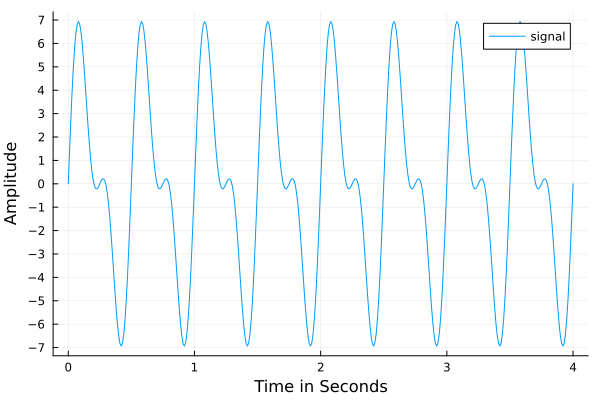

In [2]:
dt = 0.01
t = 0:dt:4
y = 3*sin.(4*2*pi*t) + 5*sin.(2*2*pi*t)
plot(t, y, yticks=-7:1:7, label="signal",
     xlabel="Time in Seconds", ylabel="Amplitude")

In [3]:
#savefig("applyfftsignal.png")

The output of the ``fft`` gives a spectral plot of the signal.

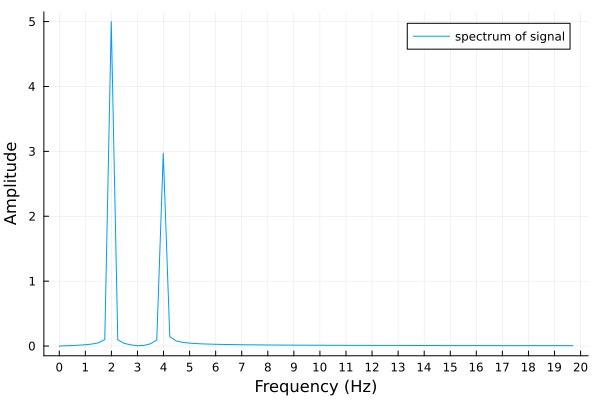

In [4]:
F = fft(y)
n = length(y)/2
amps = abs.(F)/n
freq = [0:79]/(2*n*dt)
plot(freq, amps[1:80], xticks=0:1:20, label="spectrum of signal",
     ylabel="Amplitude", xlabel="Frequency (Hz)")

In [5]:
amps[2]

0.004085959392879016

In [6]:
amps[3]

0.008508013924776042

In [7]:
#savefig("applyfftspectrum.png")

Random noise, normally distributed of magnitude 0.3 is added to the signal.

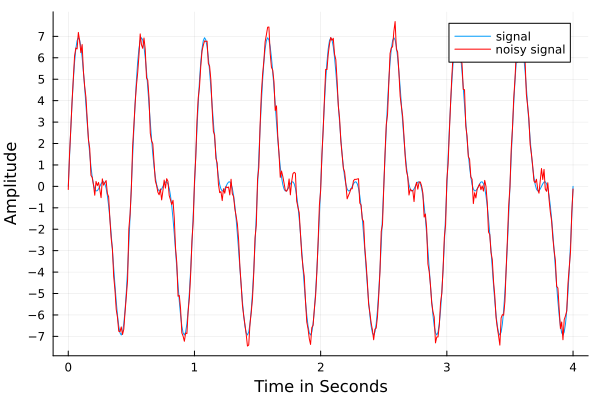

In [8]:
ynoise = y + 0.3*randn(length(y))
dt = 0.01
t = 0:dt:4
y = 3*sin.(4*2*pi*t) + 5*sin.(2*2*pi*t)
plot(t, y, yticks=-7:1:7, label="signal",
     xlabel="Time in Seconds", ylabel="Amplitude")
plot!(t, ynoise, color="red", label="noisy signal")

In [9]:
#savefig("applyfftnoisysignal.png")

### 2. spectral analysis with the FFT

Consider the FFT applied to the noisy signal.

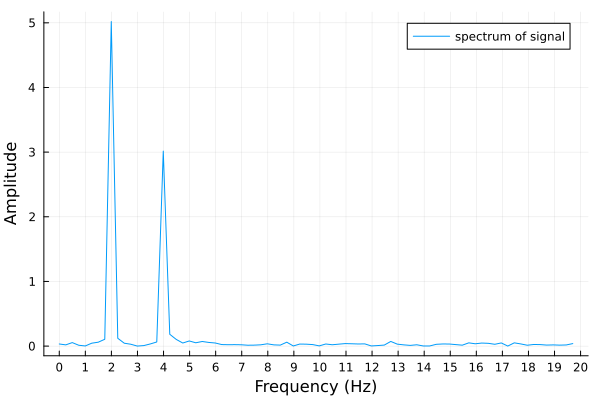

In [10]:
F = fft(ynoise)
n = length(ynoise)/2
amps = abs.(F)/n
freq = [0:79]/(2*n*dt)
plot(freq, amps[1:80], xticks=0:1:20, label="spectrum of signal",
     ylabel="Amplitude", xlabel="Frequency (Hz)")

Observe the small amplitudes which appear at all frequencies.

In [11]:
#savefig("applyfftnoisyspectrum.png")

The ``filteredF`` replaces all numbers that are less than 50 in absolute value by zero.

In [12]:
filteredF = [x*Int(abs(x) > 50) for x in F];

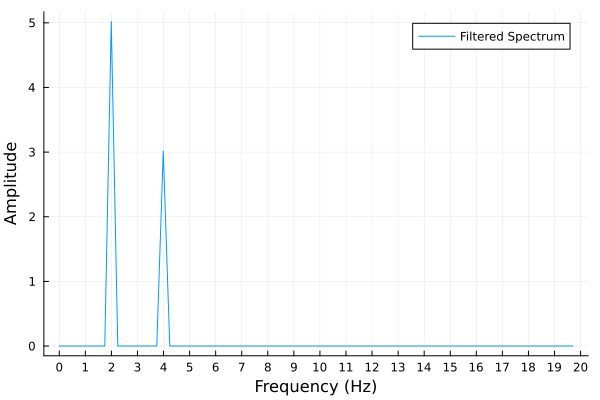

In [13]:
n = length(filteredF)/2
amps2 = abs.(filteredF)/n
freq2 = [0:79]/(2*n*dt)
plot(freq2, amps2[1:80], xticks=0:1:20, label="Filtered Spectrum",
     ylabel="Amplitude", xlabel="Frequency (Hz)")

In [14]:
#savefig("applyfftfilteredspectrum.png")

To construct the filtered signal, we apply the ``ifft`` to the filtered spectrum.  We plot only the real parts of the filtered signal.

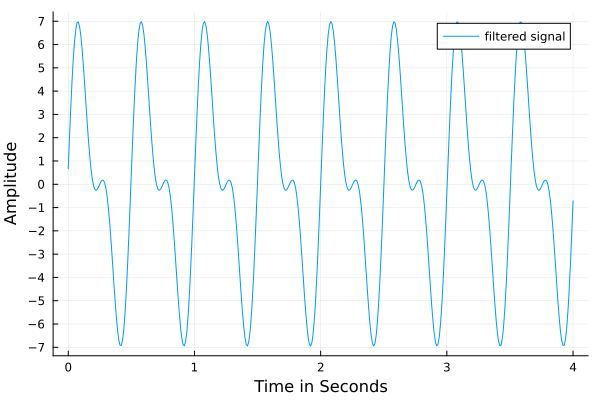

In [15]:
yfiltered = ifft(filteredF)
plot(t, real(yfiltered), yticks=-7:1:7, label="filtered signal",
     xlabel="Time in Seconds", ylabel="Amplitude")

In [16]:
#savefig("applyfftfilteredsignal.png")